# Convergence plot variations

Fig.~8-style grids for four test sets × two metric pairs:

| Test set | Point estimate | Aggregation across mocks |
|---|---|---|
| Coverage LH | posterior mean | median |
| Cosmic variance (fixed-cosmo **mean**) | **MAP** (1D KDE mode) + posterior cov for FoM/FoB | none (1 obs) |
| Cosmic variance (fixed-cosmo **samples**) | posterior mean | median |
| SHAMe OOD mock ($\bar n=2.2\times10^{-4}$) | **MAP** + posterior cov for FoM/FoB | none (1 obs) |

Metric pairs (2×3 panels, one column per $\Omega_\mathrm{c}$, $\sigma_8$, $b_1$):
1. FoM (top) / FoB (bottom)
2. MSE (top) / $|\hat\theta-\theta_{\mathrm{true}}|$ (bottom)

Training grid: $n_\mathrm{cosmo}\in\{500,\ldots,10000\}$, $b_x\in\{1,\ldots,32\}$, noisy fiducial models (`_best-rand30`).


In [1]:
import sys
import pickle
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt
from scipy.stats import chi2

import paths
import data_loader
import utils_plot
import utils_inference as ui

%load_ext autoreload
%autoreload 2


In [2]:
# --- Fiducial config (matches paper figures / submit_inf_train) ---
TAG_INF_BEST_SUFFIX = "_best-rand30"
data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnoisenest_p9_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

STATISTICS_ARR_FID = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
]
TAGS_MASK_FID = ["", "_kpgm0.25", "_kb0.25", "_kb0.25_kpgm0.25"]
COLORS_FID = ["#79D0EC", "#6BB756", "#9D86E0", "#B32168"]

STAT_LABELS_SHORT = {
    "pk": r"$P_\mathrm{gg}$",
    "bispec": r"$B_\mathrm{ggg}$",
    "pgm": r"$P_\mathrm{gm}$",
}


def get_stat_label_short(statistics):
    return " + ".join(STAT_LABELS_SHORT[s] for s in statistics)


TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST_FIXED = "_biasshame_noisebest_p0_n1"
TAG_NOISE_TEST_FIXED = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST_MEAN = "_mean"

TAG_PARAMS_TEST_COV = "_coverage_p5_n1000"
TAG_BIASPARAMS_TEST_COV = "_biasnoisecoverage_p9_n1000"
TAG_NOISE_TEST_COV = "_noise_unit_coverage_p5_n1000"

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"

n_cosmo_arr = [500, 1000, 2000, 4000, 6000, 8000, 10000]
bx_arr = [1, 2, 4, 8, 16, 32]
N_COVERAGE = 1000
N_MAP_GRID = 500  # KDE grid for marginal MAP

dir_sbi = paths.DIR_RESULTS / "results_sbi"

FIG_DIR = REPO_ROOT / "figures" / "2026-08-07_convergence_variations"
FIG_DIR_LATEST = REPO_ROOT / "figures" / "convergence_variations_latest"
OVERWRITE_FIGURES = True
FIG_EXT = "png"

CACHE_DIR = REPO_ROOT / "figures" / "convergence_variations_cache"
OVERWRITE_CACHE = False


def load_or_build(name, builder, *, overwrite=None):
    if overwrite is None:
        overwrite = OVERWRITE_CACHE
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    path = CACHE_DIR / f"{name}.pkl"
    if path.is_file() and not overwrite:
        print(f"Loaded cache: {path}")
        with open(path, "rb") as f:
            return pickle.load(f)
    obj = builder()
    with open(path, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Wrote cache: {path}")
    return obj


def save_figure(fig, name, ext=FIG_EXT):
    filename = f"{name}.{ext}"
    paths_out = [FIG_DIR / filename, FIG_DIR_LATEST / filename]
    if any(p.exists() for p in paths_out) and not OVERWRITE_FIGURES:
        print(f"Skipping save (exists, overwrite=False): {filename}")
        return
    fig.canvas.draw_idle()
    for path in paths_out:
        path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(path, bbox_inches="tight", facecolor="white", edgecolor="none")
        print(f"Saved: {path}")


In [3]:
# --- Metric definitions (physical b1; FoB/FoM in Ωc, σ8, b1) ---
PARAM_NAMES_FOB = ["omega_cold", "sigma8_cold", "b1"]
FOB_KEYS = ["omega_m", "sigma8", "b1"]
PARAMS_TRACK = {
    "omega_m": "omega_cold",
    "sigma8": "sigma8_cold",
    "b1": "b1",
}
FOB_LABELS = {
    "omega_m": r"$\Omega_\mathrm{c}$",
    "sigma8": r"$\sigma_8$",
    "b1": r"$b_1$",
}
FOM3_YLABEL = r"FoM($\Omega_\mathrm{c}$, $\sigma_8$, $b_1$)"
FOB3_YLABEL = r"FoB($\Omega_\mathrm{c}$, $\sigma_8$, $b_1$) / $1\sigma$"
_CHI2_PPF_1SIG = 0.682689492137
FOB_RIDGE = 1e-8
NCOSMO_ALPHA_LO, NCOSMO_ALPHA_HI = 0.15, 1.0
XLABEL_NSIMS = r"$N_\mathrm{train}$ ($= N_\mathrm{cosmo} \times N_\mathrm{bias}$)"


def fob_chi2_sqrt_limit(ndims):
    return float(np.sqrt(chi2.ppf(_CHI2_PPF_1SIG, int(ndims))))


def compute_fob(theta_pred_row, cov, param_names, theta_true, param_vary):
    # FoB in physical (ω_c, σ8, b1); unreparameterize if needed.
    names = list(param_names)
    tp = np.asarray(theta_pred_row, dtype=float)
    cov_arr = np.asarray(cov, dtype=float)
    theta_true = np.asarray(theta_true, dtype=float)

    if ui.has_reparameterized_sigma8_columns(names):
        theta_true_rep, names_rep = ui.reparameterize_theta(theta_true, param_vary)
        names_rep = list(names_rep)
        true_aligned = np.array(
            [float(theta_true_rep[names_rep.index(pn)]) for pn in names], dtype=float,
        )
        tp_u, tt_u, cov_u, names_u = ui.unreparameterize_prediction_block(
            tp[None, :], true_aligned[None, :], names, covs_per_sample=cov_arr[None, :, :],
        )
        tp, true_vec, cov_arr, names = tp_u[0], tt_u[0], cov_u[0], list(names_u)
    else:
        names_phys = list(param_vary)
        true_vec = np.array(
            [float(theta_true[names_phys.index(pn)]) for pn in names], dtype=float,
        )

    true_fob = np.array([true_vec[names.index(pn)] for pn in PARAM_NAMES_FOB], dtype=float)
    mu = np.array([float(tp[names.index(pn)]) for pn in PARAM_NAMES_FOB], dtype=float)
    idx_fob = [names.index(pn) for pn in PARAM_NAMES_FOB]
    cov_sub = cov_arr[np.ix_(idx_fob, idx_fob)] + FOB_RIDGE * np.eye(len(idx_fob))
    fob = {}
    for key, i in zip(FOB_KEYS, range(len(FOB_KEYS))):
        sig = np.sqrt(cov_sub[i, i])
        fob[key] = abs(mu[i] - true_fob[i]) / sig if sig > 0 else np.nan
    diff = mu - true_fob
    sign, _ = np.linalg.slogdet(cov_sub)
    cov_inv = np.linalg.inv(cov_sub) if sign > 0 else np.linalg.pinv(cov_sub)
    fob3 = float(np.sqrt(diff @ cov_inv @ diff))
    return fob, fob3


def compute_fom_key_block(cov, param_names, theta_pred_row=None):
    # FoM in physical (ω_c, σ8, b1); unreparameterizes cov if needed.
    names = list(param_names)
    cov_arr = np.asarray(cov, dtype=float)
    if ui.has_reparameterized_sigma8_columns(names):
        if theta_pred_row is None:
            raise ValueError("theta_pred_row required to unreparameterize FoM covariance")
        tp = np.asarray(theta_pred_row, dtype=float)
        sigma8 = float(tp[names.index("sigma8_cold")])
        cov_arr = ui.scale_covariance_unreparameterize_approx(cov_arr, names, sigma8)
        _, names = ui.unreparameterize_theta(tp, names)
        names = list(names)
    idx_fob = [names.index(pn) for pn in PARAM_NAMES_FOB]
    cov_sub = cov_arr[np.ix_(idx_fob, idx_fob)]
    fom_marg = {}
    for key, i in zip(FOB_KEYS, range(len(FOB_KEYS))):
        sig = np.sqrt(cov_sub[i, i])
        fom_marg[key] = 1.0 / sig if sig > 0 else np.nan
    det = np.linalg.det(cov_sub)
    fom_3d = 1.0 / np.sqrt(det) if det > 0 else np.nan
    return fom_marg, float(fom_3d)


In [4]:
# --- Tag builders + sample I/O ---
def build_tag_inf_conv(bx_val, n_cosmo_val, statistics, tag_masks):
    tag_stats = f"_{'_'.join(statistics)}"
    return (
        f"_{data_mode}{tag_stats}{tag_masks}{TAG_PARAMS_TRAIN}"
        f"{TAG_BIASPARAMS_TRAIN}{TAG_NOISE_TRAIN}{tag_reparam}"
        f"_bx{bx_val}_ntrain{n_cosmo_val}{TAG_INF_BEST_SUFFIX}"
    )


def build_tag_test_coverage(statistics, tag_masks):
    tag_stats = f"_{'_'.join(statistics)}"
    return (
        f"_{data_mode}{tag_stats}{tag_masks}"
        f"{TAG_PARAMS_TEST_COV}{TAG_BIASPARAMS_TEST_COV}{TAG_NOISE_TEST_COV}"
    )


def build_tag_test_cv(statistics, tag_masks, *, mean=False):
    tag_stats = f"_{'_'.join(statistics)}"
    tag_mean = TAG_DATAGEN_TEST_MEAN if mean else ""
    return (
        f"_{data_mode}{tag_stats}{tag_masks}"
        f"{TAG_PARAMS_TEST_FIXED}{TAG_BIASPARAMS_TEST_FIXED}{TAG_NOISE_TEST_FIXED}"
        f"{tag_mean}"
    )


def build_tag_test_ood(statistics, tag_masks, tag_mock=None):
    tag_mock = TAG_MOCK_SHAME if tag_mock is None else tag_mock
    tag_stats = f"_{'_'.join(statistics)}"
    return f"_shame{tag_stats}{tag_masks}{tag_mock}"


def _coverage_samples_path(tag_inf, tag_test):
    base = dir_sbi / f"sbi{tag_inf}"
    fn = base / f"samples_test{tag_test}_pred.npy"
    if fn.is_file():
        return fn, "done"
    fn_ip = base / f"samples_test{tag_test}_pred_inprogress.npy"
    if fn_ip.is_file():
        return fn_ip, "inprogress"
    return None, None


def _finite_sample_rows(samples_arr):
    if samples_arr.ndim != 3:
        raise ValueError(f"expected 3D samples, got {samples_arr.shape}")
    has_any = np.any(np.isfinite(samples_arr), axis=(0, 2))
    n_obs, n_par = samples_arr.shape[1], samples_arr.shape[2]
    theta_pred = np.full((n_obs, n_par), np.nan, dtype=float)
    if np.any(has_any):
        theta_pred[has_any] = np.nanmean(samples_arr[:, has_any, :], axis=0)
    return np.where(np.all(np.isfinite(theta_pred), axis=1))[0]


def _point_estimate_row(samples_i, param_names, point_est):
    # samples_i: (n_draw, n_par)
    if point_est == "mean":
        return np.nanmean(samples_i, axis=0)
    if point_est == "map":
        return np.asarray(
            ui.get_posterior_maxes(samples_i, list(param_names), n_grid=N_MAP_GRID),
            dtype=float,
        )
    raise ValueError(f"unknown point_est={point_est!r}")


def _agg(values, how):
    arr = np.asarray(values, dtype=float)
    if how == "median":
        return float(np.nanmedian(arr))
    if how == "mean":
        return float(np.nanmean(arr))
    if how == "identity":
        return float(arr[0]) if arr.size else np.nan
    raise ValueError(f"unknown aggregate={how!r}")


In [5]:
def load_grid_metrics(
    bx, n_cosmo, statistics, tag_masks, tag_test, *,
    tag_params_test, tag_biasparams_test, n_target,
    point_est="mean", aggregate="median",
    ood=False, data_mode_test=None, tag_mock=None,
):
    # FoM/FoB/MSE/|Δ| for one (bx, n_cosmo) grid point.
    # point_est: 'mean' (posterior mean) or 'map' (marginal KDE mode).
    # aggregate: 'median' / 'mean' across mocks, or 'identity' (first/only obs).
    # FoM/FoB use the posterior covariance as the error region around the point estimate.
    tag_inf = build_tag_inf_conv(bx, n_cosmo, statistics, tag_masks)
    label = utils_plot.get_stat_label(statistics)
    base_info = {
        "label": label, "bx": bx, "n_cosmo": n_cosmo,
        "tag_inf": tag_inf, "path": None, "kind": None,
        "n_stored": 0, "n_cov": 0, "status": "missing", "message": "",
    }

    model_dir = dir_sbi / f"sbi{tag_inf}"
    if not model_dir.is_dir():
        base_info["message"] = f"no model directory: {model_dir.name}"
        return None, base_info

    fn, kind = _coverage_samples_path(tag_inf, tag_test)
    base_info["kind"] = kind
    if fn is None:
        base_info["message"] = f"no samples under {model_dir.name} for tag_test={tag_test}"
        return None, base_info

    base_info["path"] = str(fn)
    samples_arr = np.load(fn)
    fn_pn = model_dir / "param_names.txt"
    if not fn_pn.is_file():
        base_info["status"] = "bad_model"
        base_info["message"] = f"missing param_names.txt in {model_dir.name}"
        return None, base_info
    if samples_arr.ndim == 2:
        samples_arr = samples_arr[:, None, :]
    if samples_arr.ndim != 3:
        base_info["status"] = "bad_shape"
        base_info["message"] = f"expected 2D/3D samples, got {samples_arr.shape}"
        return None, base_info

    n_stored = int(samples_arr.shape[1])
    base_info["n_stored"] = n_stored
    if n_stored == 0:
        base_info["status"] = "empty"
        base_info["message"] = f"n_obs=0 in {fn.name}"
        return None, base_info

    param_names_all = list(np.loadtxt(fn_pn, dtype=str))
    rows = _finite_sample_rows(samples_arr)
    n_use = int(rows.size)
    base_info["n_cov"] = n_use
    n_nan_rows = n_stored - n_use

    if n_use == 0:
        base_info["status"] = "all_nan"
        base_info["message"] = f"all {n_stored} obs unusable in {fn.name}"
        return None, base_info

    if kind == "inprogress" or n_stored < n_target or n_use < n_target:
        parts = [f"loaded {fn.name} ({kind})", f"usable={n_use}/{n_target}"]
        if n_nan_rows:
            parts.append(f"dropped {n_nan_rows} failed rows")
        base_info["status"] = "incomplete"
        base_info["message"] = "; ".join(parts)
    else:
        base_info["status"] = "complete"
        base_info["message"] = (
            f"loaded {fn.name} (done): usable={n_use}/{n_target}"
            + (f" (dropped {n_nan_rows} failed)" if n_nan_rows else "")
        )

    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    if ood:
        theta_true_all = data_loader.load_theta_ood(
            data_mode_test, tag_mock,
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
    else:
        theta_true_all = data_loader.load_theta_test(
            tag_params_test, tag_biasparams_test,
            cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
        )
    if theta_true_all.ndim == 1:
        theta_true_all = np.tile(theta_true_all, (samples_arr.shape[1], 1))
    theta_true_all = theta_true_all[rows]
    param_vary_list = list(param_vary)

    fob_lists = {key: [] for key in FOB_KEYS}
    fom_lists = {key: [] for key in FOB_KEYS}
    mse_lists = {key: [] for key in PARAMS_TRACK}
    absdelta_lists = {key: [] for key in PARAMS_TRACK}
    fob3_list, fom3_list = [], []

    for j, i_obs in enumerate(rows):
        samples_i = samples_arr[:, i_obs, :]
        theta_hat = _point_estimate_row(samples_i, param_names_all, point_est)
        cov_i = np.cov(samples_i.T)
        fob, fob3 = compute_fob(
            theta_hat, cov_i, param_names_all, theta_true_all[j], param_vary,
        )
        fom_marg, fom_3d = compute_fom_key_block(
            cov_i, param_names_all, theta_pred_row=theta_hat,
        )
        for key in FOB_KEYS:
            fob_lists[key].append(fob[key])
            fom_lists[key].append(fom_marg[key])
        fob3_list.append(fob3)
        fom3_list.append(fom_3d)

        theta_phys, names_phys = ui.unreparameterize_theta(theta_hat, param_names_all)
        names_phys = list(names_phys)
        for key, pname in PARAMS_TRACK.items():
            true_val = float(theta_true_all[j, param_vary_list.index(pname)])
            pred_val = float(theta_phys[names_phys.index(pname)])
            err = pred_val - true_val
            mse_lists[key].append(err ** 2)
            absdelta_lists[key].append(abs(err))

    row = {
        "bx": bx, "n_cosmo": n_cosmo, "n_sims": bx * n_cosmo,
        "n_cov": n_use, "n_stored": n_stored, "status": base_info["status"],
        "kind": kind, "point_est": point_est, "aggregate": aggregate,
    }
    for key in FOB_KEYS:
        row[f"fom_{key}"] = _agg(fom_lists[key], aggregate)
        row[f"fob_{key}"] = _agg(fob_lists[key], aggregate)
    for key in PARAMS_TRACK:
        row[f"mse_{key}"] = _agg(mse_lists[key], aggregate)
        row[f"absdelta_{key}"] = _agg(absdelta_lists[key], aggregate)
    row["fom_3d"] = _agg(fom3_list, aggregate)
    row["fob3"] = _agg(fob3_list, aggregate)
    return row, base_info


def collect_grid(
    statistics, tag_masks, n_cosmo_values, bx_values, *,
    tag_test, tag_params_test, tag_biasparams_test, n_target,
    point_est="mean", aggregate="median", grid_label="grid", verbose=True,
    ood=False, data_mode_test=None, tag_mock=None,
):
    label = utils_plot.get_stat_label(statistics)
    rows = []
    n_complete = n_incomplete = n_missing = 0
    if verbose:
        print(f"=== {grid_label}: {label} ===")
        print(f"tag_test={tag_test}  point_est={point_est}  aggregate={aggregate}")
        print(
            f"grid: {len(bx_values)} bx × {len(n_cosmo_values)} n_cosmo "
            f"= {len(bx_values) * len(n_cosmo_values)} points\n"
        )
    for bx in bx_values:
        for n_cosmo in n_cosmo_values:
            m, info = load_grid_metrics(
                bx, n_cosmo, statistics, tag_masks, tag_test,
                tag_params_test=tag_params_test,
                tag_biasparams_test=tag_biasparams_test,
                n_target=n_target,
                point_est=point_est,
                aggregate=aggregate,
                ood=ood,
                data_mode_test=data_mode_test,
                tag_mock=tag_mock,
            )
            prefix = f"[{label}] bx={bx}, n_cosmo={n_cosmo}"
            if m is None:
                n_missing += 1
                if verbose:
                    print(f"MISSING  {prefix}: {info['message']}")
                continue
            rows.append(m)
            if info["status"] == "complete":
                n_complete += 1
                if verbose:
                    print(f"OK       {prefix}: {info['message']}")
            else:
                n_incomplete += 1
                if verbose:
                    print(f"INCOMPLETE {prefix}: {info['message']}")
    n_expected = len(bx_values) * len(n_cosmo_values)
    if verbose:
        print(
            f"\nSummary [{label}]: {len(rows)} loaded "
            f"({n_complete} complete, {n_incomplete} incomplete) / {n_expected}; "
            f"{n_missing} missing\n"
        )
    return pd.DataFrame(rows) if rows else pd.DataFrame()


def collect_all_combos(test_cfg, *, verbose=True):
    # test_cfg: dict with keys used by collect_grid + cache_prefix.
    frames = []
    for statistics, tag_masks in zip(STATISTICS_ARR_FID, TAGS_MASK_FID):
        label = utils_plot.get_stat_label(statistics)
        cache_name = (
            f"{test_cfg['cache_prefix']}_"
            + "_".join(statistics)
            + (tag_masks or "_nomask")
        )
        df = load_or_build(
            cache_name,
            lambda s=statistics, m=tag_masks: collect_grid(
                s, m, n_cosmo_arr, bx_arr,
                tag_test=test_cfg["tag_test_fn"](s, m),
                tag_params_test=test_cfg["tag_params_test"],
                tag_biasparams_test=test_cfg["tag_biasparams_test"],
                n_target=test_cfg["n_target"],
                point_est=test_cfg["point_est"],
                aggregate=test_cfg["aggregate"],
                grid_label=test_cfg["grid_label"],
                verbose=verbose,
                ood=test_cfg.get("ood", False),
                data_mode_test=test_cfg.get("data_mode_test"),
                tag_mock=test_cfg.get("tag_mock"),
            ),
        )
        if df.empty:
            print(f"No data for {test_cfg['grid_label']} / {label}")
            continue
        df = df.copy()
        df["stat_combo"] = label
        frames.append(df)
        print(f"{test_cfg['grid_label']} {label}: {len(df)} grid points")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


TEST_CFGS = {
    "coverage": dict(
        cache_prefix="df_cov_medmean",
        grid_label="Coverage",
        tag_test_fn=build_tag_test_coverage,
        tag_params_test=TAG_PARAMS_TEST_COV,
        tag_biasparams_test=TAG_BIASPARAMS_TEST_COV,
        n_target=N_COVERAGE,
        point_est="mean",
        aggregate="median",
    ),
    "cv_mean": dict(
        cache_prefix="df_cvmean_map",
        grid_label="CV mean (MAP)",
        tag_test_fn=lambda s, m: build_tag_test_cv(s, m, mean=True),
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tag_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
        n_target=1,
        point_est="map",
        aggregate="identity",
    ),
    "cv_sample": dict(
        cache_prefix="df_cvsample_medmean",
        grid_label="CV sample",
        tag_test_fn=lambda s, m: build_tag_test_cv(s, m, mean=False),
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tag_biasparams_test=TAG_BIASPARAMS_TEST_FIXED,
        n_target=N_COVERAGE,
        point_est="mean",
        aggregate="median",
    ),
    "ood": dict(
        cache_prefix="df_ood_map",
        grid_label="SHAMe OOD (MAP)",
        tag_test_fn=build_tag_test_ood,
        tag_params_test="",
        tag_biasparams_test="",
        n_target=1,
        point_est="map",
        aggregate="identity",
        ood=True,
        data_mode_test=DATA_MODE_TEST_SHAME,
        tag_mock=TAG_MOCK_SHAME,
    ),
}


In [6]:
# --- Plotting (fig-8 style) ---
def n_cosmo_alpha(n_cosmo, n_cosmo_values=None, lo=NCOSMO_ALPHA_LO, hi=NCOSMO_ALPHA_HI):
    n_cosmo_values = sorted(n_cosmo_values if n_cosmo_values is not None else n_cosmo_arr)
    if len(n_cosmo_values) == 1:
        return hi
    t = n_cosmo_values.index(int(n_cosmo)) / (len(n_cosmo_values) - 1)
    return lo + t * (hi - lo)


def _draw_nsims_curves(ax, df, y_col, color, *, n_cosmo_values=None, y_scale=1.0):
    n_cosmo_values = sorted(
        n_cosmo_values if n_cosmo_values is not None else df["n_cosmo"].unique()
    )
    rgb = mcolors.to_rgb(color)
    for n_cosmo in n_cosmo_values:
        grp = df[df["n_cosmo"] == n_cosmo].sort_values("n_sims")
        if grp.empty or y_col not in grp.columns:
            continue
        rgba = (*rgb, n_cosmo_alpha(n_cosmo, n_cosmo_values))
        if len(grp) >= 1:
            ax.plot(
                grp["n_sims"], grp[y_col] / y_scale,
                color=rgba, ls="-", lw=1.5, zorder=1,
            )


def _n_cosmo_legend_handles(n_cosmo_values):
    handles, labels = [], []
    for n_cosmo in sorted(n_cosmo_values):
        alpha = n_cosmo_alpha(n_cosmo, n_cosmo_values)
        handles.append(plt.Line2D([0], [0], color=(0.5, 0.5, 0.5, alpha), ls="-", lw=1.5))
        labels.append(rf"$N_\mathrm{{cosmo}}={n_cosmo}$")
    return handles, labels


def _conv_legend_outside(
    fig, stat_handles=None, stat_labels=None, n_cosmo_values=None,
    *, fontsize=11, bbox_to_anchor=(0.91, 0.5), right=0.90,
):
    handles, labels = [], []
    if stat_handles is not None:
        handles.extend(stat_handles)
        labels.extend(stat_labels)
    if n_cosmo_values is not None:
        h_nc, l_nc = _n_cosmo_legend_handles(n_cosmo_values)
        handles.extend(h_nc)
        labels.extend(l_nc)
    fig.legend(
        handles, labels, fontsize=fontsize, loc="center left",
        bbox_to_anchor=bbox_to_anchor, frameon=False, labelcolor="black",
    )
    fig.subplots_adjust(right=right)


def plot_conv_fom_fob(df_all, *, save_name=None, title=None):
    if df_all.empty:
        print("No data for FoM/FoB plot")
        return
    missing = [
        f"{p}_{k}" for k in FOB_KEYS for p in ("fom", "fob")
        if f"{p}_{k}" not in df_all.columns
    ]
    if missing:
        raise KeyError("missing columns: " + ", ".join(missing))
    full_labels = [utils_plot.get_stat_label(s) for s in STATISTICS_ARR_FID]
    short_labels = [get_stat_label_short(s) for s in STATISTICS_ARR_FID]
    n_cosmo_values = sorted(df_all["n_cosmo"].unique())
    gauss_ref = np.sqrt(2.0 / np.pi)
    lim1 = fob_chi2_sqrt_limit(1)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
    if title:
        fig.suptitle(title, y=1.02, fontsize=13)
    for ax, key in zip(axes[0], FOB_KEYS):
        for full_label, color in zip(full_labels, COLORS_FID):
            sub = df_all[df_all["stat_combo"] == full_label]
            _draw_nsims_curves(ax, sub, f"fom_{key}", color, n_cosmo_values=n_cosmo_values)
        ax.set_title(FOB_LABELS[key], fontsize=16, fontweight="bold", pad=8)
        ax.set_ylabel("FoM")
        ax.set_yscale("log")
        ax.set_xscale("log")
    for ax, key in zip(axes[1], FOB_KEYS):
        for full_label, color in zip(full_labels, COLORS_FID):
            sub = df_all[df_all["stat_combo"] == full_label]
            _draw_nsims_curves(ax, sub, f"fob_{key}", color, n_cosmo_values=n_cosmo_values)
        ax.axhline(gauss_ref, color="k", ls="--", lw=1, alpha=0.7)
        ax.axhline(lim1, color="gray", ls=":", lw=1, alpha=0.7)
        ax.set_ylabel("FoB")
        ax.set_xscale("log")
    fob_vals = []
    for key in FOB_KEYS:
        col = f"fob_{key}"
        if col in df_all.columns:
            fob_vals.extend(df_all[col].dropna().tolist())
    if fob_vals:
        ymin, ymax = float(np.nanmin(fob_vals)), float(np.nanmax(fob_vals))
        pad = 0.05 * (ymax - ymin) if ymax > ymin else 0.1
        for ax in axes[1]:
            ax.set_ylim(max(0.0, ymin - pad), ymax + pad)
    for ax in axes[1]:
        ax.set_xlabel(XLABEL_NSIMS)
    stat_handles = [plt.Line2D([0], [0], color=c, ls="-", lw=1.5) for c in COLORS_FID]
    fig.tight_layout()
    _conv_legend_outside(
        fig, stat_handles=stat_handles, stat_labels=short_labels,
        n_cosmo_values=n_cosmo_values,
    )
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def plot_conv_fom3d_fob3(
    df_all, *, save_name=None, title=None,
    statistics_arr=None, colors=None,
    figsize=(5.6, 6), label_fontsize=15, tick_fontsize=12,
):
    """Combined 3D FoM / FoB for (Ωc, σ8, b1).

    statistics_arr / colors: subset of STATISTICS_ARR_FID / COLORS_FID (default: all).
    """
    if df_all.empty:
        print("No data for FoM3d / FoB3 plot")
        return
    for col in ("fom_3d", "fob3"):
        if col not in df_all.columns:
            raise KeyError(f"missing column: {col}")
    statistics_arr = statistics_arr if statistics_arr is not None else STATISTICS_ARR_FID
    colors = colors if colors is not None else COLORS_FID[: len(statistics_arr)]
    full_labels = [utils_plot.get_stat_label(s) for s in statistics_arr]
    short_labels = [get_stat_label_short(s) for s in statistics_arr]
    n_cosmo_values = sorted(df_all["n_cosmo"].unique())
    ref3 = fob_chi2_sqrt_limit(3)
    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True)
    if title:
        fig.suptitle(title, y=1.02, fontsize=13)
    for full_label, color in zip(full_labels, colors):
        sub = df_all[df_all["stat_combo"] == full_label]
        _draw_nsims_curves(axes[0], sub, "fom_3d", color, n_cosmo_values=n_cosmo_values)
        _draw_nsims_curves(
            axes[1], sub, "fob3", color, n_cosmo_values=n_cosmo_values, y_scale=ref3,
        )
    axes[0].set_ylabel(FOM3_YLABEL, fontsize=label_fontsize)
    axes[0].set_yscale("log")
    axes[0].set_xscale("log")
    axes[1].axhline(1.0, color="gray", ls=":", lw=1, alpha=0.7)
    axes[1].set_ylabel(FOB3_YLABEL, fontsize=label_fontsize)
    axes[1].set_xscale("log")
    axes[1].set_xlabel(XLABEL_NSIMS, fontsize=label_fontsize)
    for ax in axes:
        ax.tick_params(axis="both", labelsize=tick_fontsize)
    show_stat_legend = len(statistics_arr) > 1
    stat_handles = (
        [plt.Line2D([0], [0], color=c, ls="-", lw=1.5) for c in colors]
        if show_stat_legend else None
    )
    stat_labels = short_labels if show_stat_legend else None
    fig.tight_layout()
    _conv_legend_outside(
        fig, stat_handles=stat_handles, stat_labels=stat_labels,
        n_cosmo_values=n_cosmo_values,
        bbox_to_anchor=(0.93, 0.5), right=0.86,
    )
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


def plot_conv_mse_absdelta(
    df_all, *, save_name=None, title=None,
    ylabel_mse="median MSE",
    ylabel_abs=r"median $|\hat{\theta}-\theta_{\mathrm{true}}|$",
):
    if df_all.empty:
        print("No data for MSE / |Δ| plot")
        return
    missing = [
        f"{p}_{k}" for k in PARAMS_TRACK for p in ("mse", "absdelta")
        if f"{p}_{k}" not in df_all.columns
    ]
    if missing:
        raise KeyError("missing columns: " + ", ".join(missing))
    full_labels = [utils_plot.get_stat_label(s) for s in STATISTICS_ARR_FID]
    short_labels = [get_stat_label_short(s) for s in STATISTICS_ARR_FID]
    n_cosmo_values = sorted(df_all["n_cosmo"].unique())
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
    if title:
        fig.suptitle(title, y=1.02, fontsize=13)
    for ax, key in zip(axes[0], PARAMS_TRACK):
        for full_label, color in zip(full_labels, COLORS_FID):
            sub = df_all[df_all["stat_combo"] == full_label]
            _draw_nsims_curves(ax, sub, f"mse_{key}", color, n_cosmo_values=n_cosmo_values)
        ax.set_title(FOB_LABELS[key], fontsize=16, fontweight="bold", pad=8)
        ax.set_ylabel(ylabel_mse)
        ax.set_yscale("log")
        ax.set_xscale("log")
    for ax, key in zip(axes[1], PARAMS_TRACK):
        for full_label, color in zip(full_labels, COLORS_FID):
            sub = df_all[df_all["stat_combo"] == full_label]
            _draw_nsims_curves(
                ax, sub, f"absdelta_{key}", color, n_cosmo_values=n_cosmo_values,
            )
        ax.set_ylabel(ylabel_abs)
        ax.set_yscale("log")
        ax.set_xscale("log")
    for ax in axes[1]:
        ax.set_xlabel(XLABEL_NSIMS)
    stat_handles = [plt.Line2D([0], [0], color=c, ls="-", lw=1.5) for c in COLORS_FID]
    fig.tight_layout()
    _conv_legend_outside(
        fig, stat_handles=stat_handles, stat_labels=short_labels,
        n_cosmo_values=n_cosmo_values,
    )
    if save_name is not None:
        save_figure(fig, save_name)
    plt.show()


## 1. Coverage

Posterior **mean** per mock; **median** of FoM / FoB / MSE / $|\Delta|$ over the coverage LH mocks.


In [7]:
df_coverage = collect_all_combos(TEST_CFGS["coverage"])
df_coverage.head()


Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cov_medmean_pk_nomask.pkl
Coverage $P_\mathrm{gg}(k)$: 42 grid points
Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cov_medmean_pk_pgm_kpgm0.25.pkl
Coverage $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$: 42 grid points
Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cov_medmean_pk_bispec_kb0.25.pkl
Coverage $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$: 42 grid points
Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cov_medmean_pk_bispec_pgm_kb0.25_kpgm0.25.pkl
Coverage $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$: 42 grid points


,bx,n_cosmo,n_sims,n_cov,n_stored,status,kind,point_est,aggregate,fom_omega_m,...,fob_b1,mse_omega_m,absdelta_omega_m,mse_sigma8,absdelta_sigma8,mse_b1,absdelta_b1,fom_3d,fob3,stat_combo
0,1,500,500,1000,1000,complete,done,mean,median,31.666212,...,0.843334,0.000829,0.028784,0.002760,0.052535,0.049368,0.222190,2927.672023,2.031957,$P_\mathrm{gg}(k)$
1,1,1000,1000,1000,1000,complete,done,mean,median,26.334100,...,0.835641,0.001540,0.039241,0.002974,0.054536,0.075829,0.275371,1752.657522,1.969638,$P_\mathrm{gg}(k)$
2,1,2000,2000,1000,1000,complete,done,mean,median,33.220193,...,0.804759,0.000532,0.023072,0.002611,0.051093,0.044160,0.210142,2563.904873,1.927284,$P_\mathrm{gg}(k)$
3,1,4000,4000,1000,1000,complete,done,mean,median,29.517773,...,0.841874,0.000580,0.024078,0.002703,0.051990,0.046583,0.215831,2163.287221,1.827543,$P_\mathrm{gg}(k)$
4,1,6000,6000,1000,1000,complete,done,mean,median,34.037194,...,0.812791,0.000476,0.021809,0.002609,0.051079,0.045391,0.213052,2796.210560,1.904259,$P_\mathrm{gg}(k)$


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_coverage_fom_fob.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_coverage_fom_fob.png


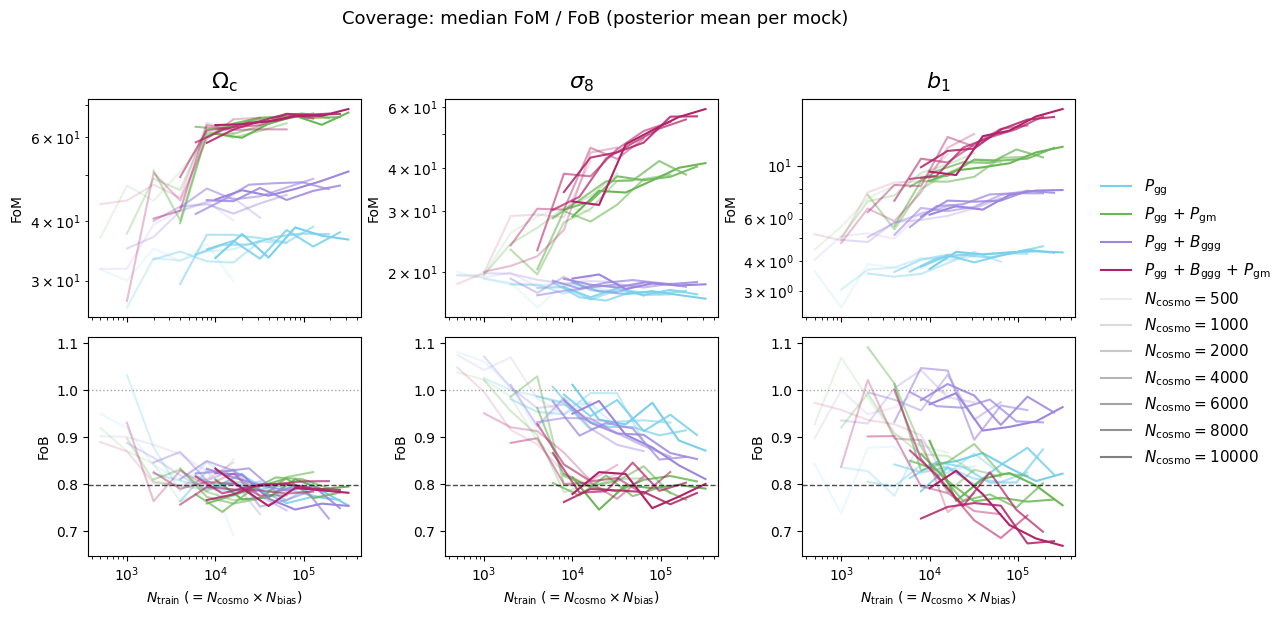

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_coverage_fom3d_fob3.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_coverage_fom3d_fob3.png


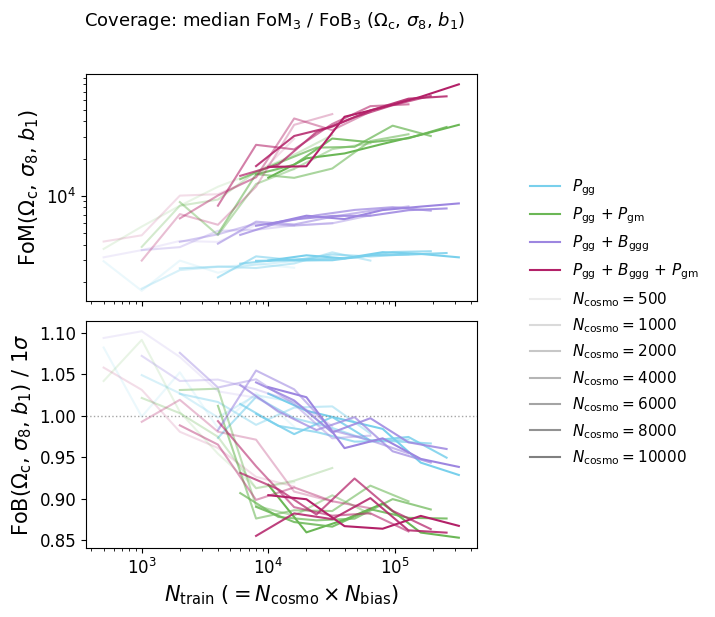

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_coverage_fom3d_fob3_pk.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_coverage_fom3d_fob3_pk.png


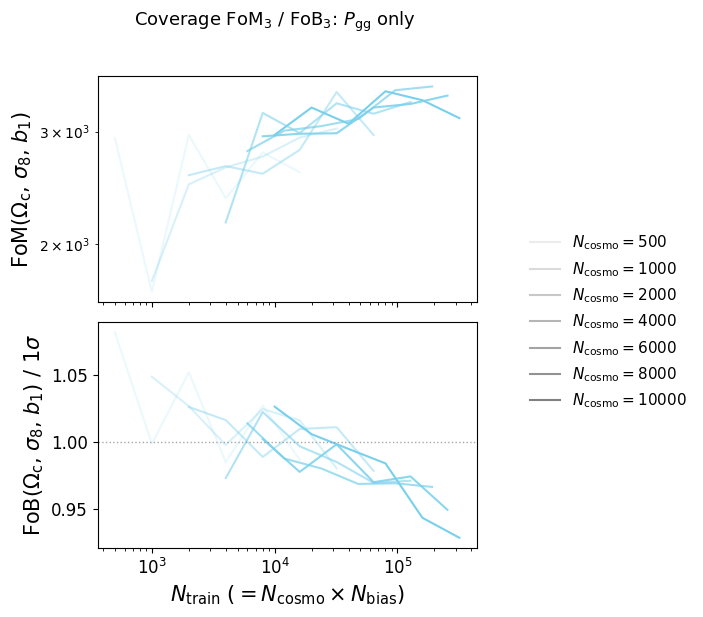

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_coverage_fom3d_fob3_pk_full.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_coverage_fom3d_fob3_pk_full.png


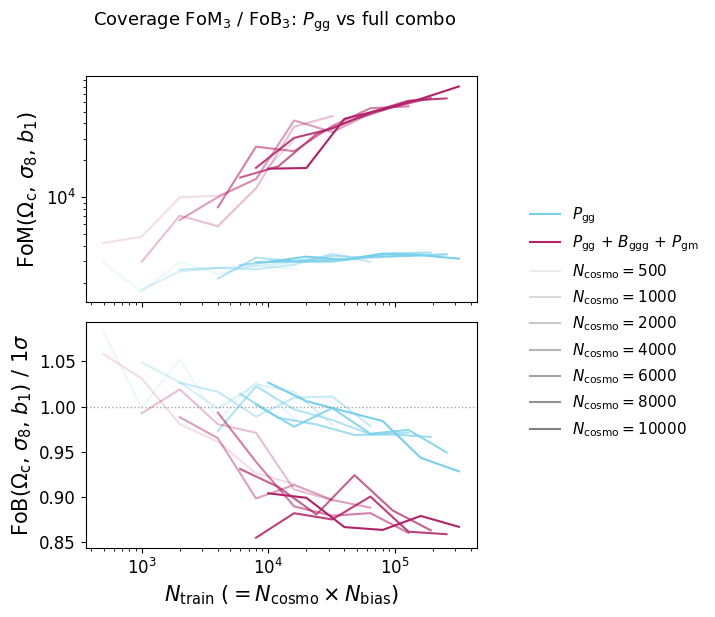

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_coverage_mse_absdelta.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_coverage_mse_absdelta.png


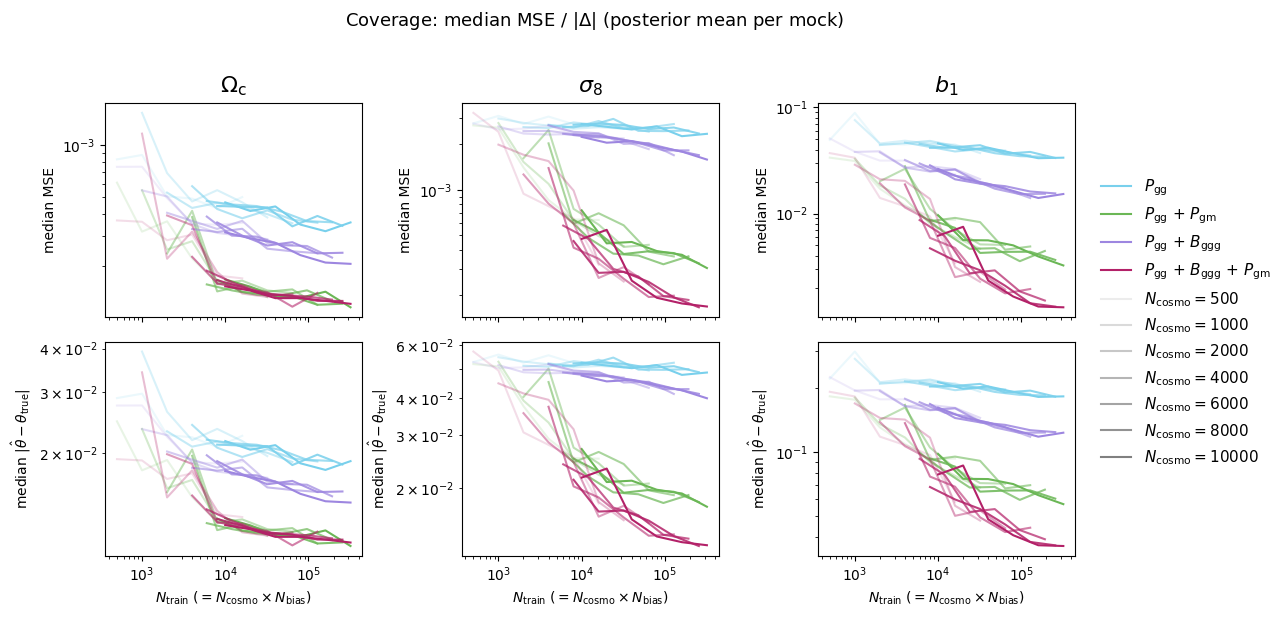

In [8]:
plot_conv_fom_fob(
    df_coverage,
    title="Coverage: median FoM / FoB (posterior mean per mock)",
    save_name="fig_coverage_fom_fob",
)
plot_conv_fom3d_fob3(
    df_coverage,
    title=r"Coverage: median FoM$_3$ / FoB$_3$ ($\Omega_\mathrm{c}$, $\sigma_8$, $b_1$)",
    save_name="fig_coverage_fom3d_fob3",
)
plot_conv_fom3d_fob3(
    df_coverage,
    statistics_arr=[STATISTICS_ARR_FID[0]],
    colors=[COLORS_FID[0]],
    title=r"Coverage FoM$_3$ / FoB$_3$: $P_\mathrm{gg}$ only",
    save_name="fig_coverage_fom3d_fob3_pk",
)
plot_conv_fom3d_fob3(
    df_coverage,
    statistics_arr=[STATISTICS_ARR_FID[0], STATISTICS_ARR_FID[3]],
    colors=[COLORS_FID[0], COLORS_FID[3]],
    title=r"Coverage FoM$_3$ / FoB$_3$: $P_\mathrm{gg}$ vs full combo",
    save_name="fig_coverage_fom3d_fob3_pk_full",
)
plot_conv_mse_absdelta(
    df_coverage,
    title=r"Coverage: median MSE / $|\Delta|$ (posterior mean per mock)",
    save_name="fig_coverage_mse_absdelta",
)


## 2. Cosmic variance — fixed-cosmo mean

Single posterior on the mean of the CV mocks. Point estimate = **marginal MAP** (1D KDE mode); FoM / FoB use that MAP with the posterior covariance as the error region. MSE / $|\Delta|$ use the MAP vs truth (no aggregation).


In [9]:
df_cv_mean = collect_all_combos(TEST_CFGS["cv_mean"])
df_cv_mean.head()


Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cvmean_map_pk_nomask.pkl
CV mean (MAP) $P_\mathrm{gg}(k)$: 1 grid points
Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cvmean_map_pk_pgm_kpgm0.25.pkl
CV mean (MAP) $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$: 1 grid points
Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cvmean_map_pk_bispec_kb0.25.pkl
CV mean (MAP) $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$: 1 grid points
Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cvmean_map_pk_bispec_pgm_kb0.25_kpgm0.25.pkl
CV mean (MAP) $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$: 42 grid points


,bx,n_cosmo,n_sims,n_cov,n_stored,status,kind,point_est,aggregate,fom_omega_m,...,fob_b1,mse_omega_m,absdelta_omega_m,mse_sigma8,absdelta_sigma8,mse_b1,absdelta_b1,fom_3d,fob3,stat_combo
0,32,10000,320000,1,1,complete,done,map,identity,45.315092,...,1.162664,0.000252,0.015885,0.015701,0.125305,0.027400,0.165529,6240.547925,2.792188,$P_\mathrm{gg}(k)$
1,32,10000,320000,1,1,complete,done,map,identity,62.086607,...,0.158164,0.000004,0.001935,0.000007,0.002625,0.000023,0.004806,115900.336253,0.229820,$P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
2,32,10000,320000,1,1,complete,done,map,identity,53.522072,...,3.439886,0.000026,0.005076,0.020851,0.144400,0.066814,0.258483,14047.938393,4.446145,"$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$"
3,1,500,500,1,1,complete,done,map,identity,42.484164,...,1.241647,0.000141,0.011857,0.004730,0.068779,0.036059,0.189892,5299.838729,1.895993,"$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\ma..."
4,1,1000,1000,1,1,complete,done,map,identity,26.813292,...,1.667380,0.000019,0.004302,0.009356,0.096726,0.113120,0.336332,3462.101079,2.968432,"$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\ma..."


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_cvmean_fom_fob.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_cvmean_fom_fob.png


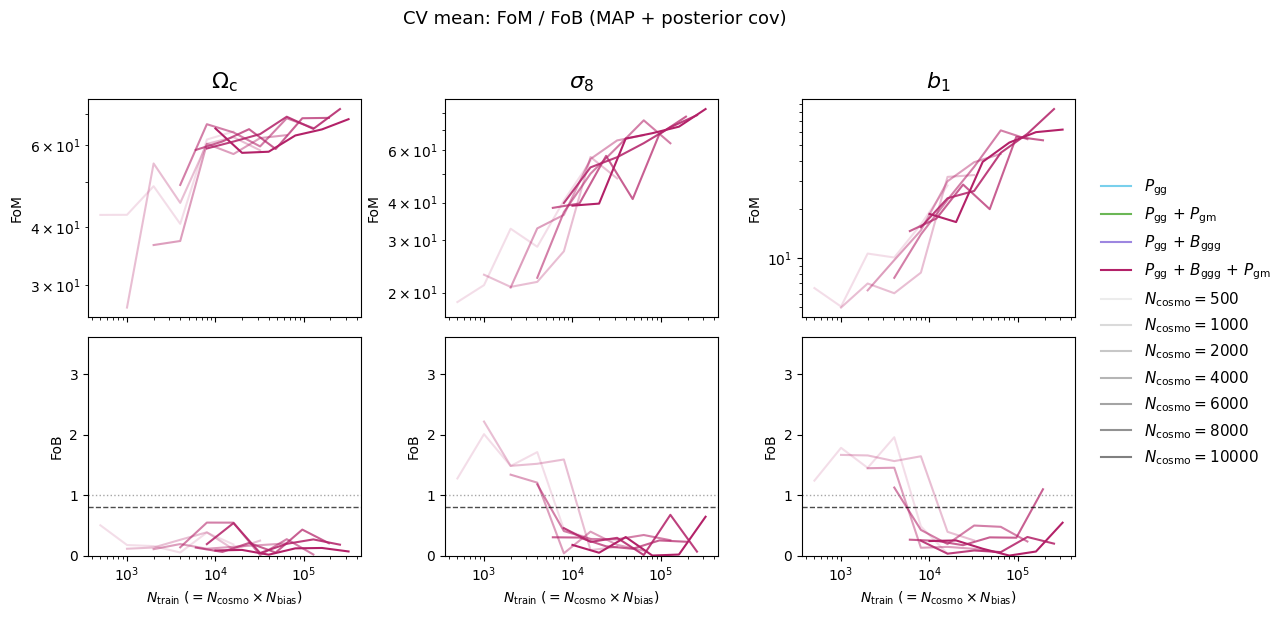

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_cvmean_mse_absdelta.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_cvmean_mse_absdelta.png


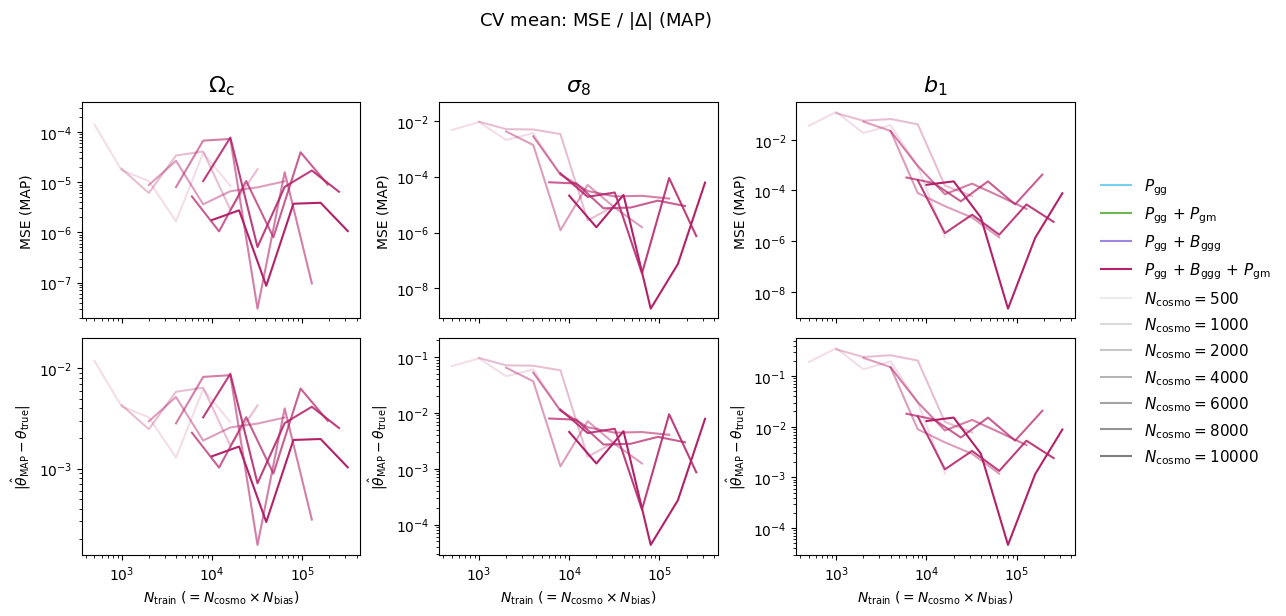

In [10]:
plot_conv_fom_fob(
    df_cv_mean,
    title="CV mean: FoM / FoB (MAP + posterior cov)",
    save_name="fig_cvmean_fom_fob",
)
plot_conv_mse_absdelta(
    df_cv_mean,
    title=r"CV mean: MSE / $|\Delta|$ (MAP)",
    ylabel_mse="MSE (MAP)",
    ylabel_abs=r"$|\hat{\theta}_{\mathrm{MAP}}-\theta_{\mathrm{true}}|$",
    save_name="fig_cvmean_mse_absdelta",
)


## 3. Cosmic variance — fixed-cosmo samples

Posterior **mean** per realization; **median** of metrics over the 1000 fixed-cosmo mocks.

Note: sample inference is currently sparse on the $(n_\mathrm{cosmo}, b_x)$ grid (often only the fiducial point). Missing grid points are printed during the load.


In [11]:
df_cv_sample = collect_all_combos(TEST_CFGS["cv_sample"])
df_cv_sample.head()


Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cvsample_medmean_pk_nomask.pkl
CV sample $P_\mathrm{gg}(k)$: 1 grid points
Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cvsample_medmean_pk_pgm_kpgm0.25.pkl
CV sample $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$: 1 grid points
Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cvsample_medmean_pk_bispec_kb0.25.pkl
CV sample $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$: 1 grid points
Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/df_cvsample_medmean_pk_bispec_pgm_kb0.25_kpgm0.25.pkl
CV sample $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$: 1 grid points


,bx,n_cosmo,n_sims,n_cov,n_stored,status,kind,point_est,aggregate,fom_omega_m,...,fob_b1,mse_omega_m,absdelta_omega_m,mse_sigma8,absdelta_sigma8,mse_b1,absdelta_b1,fom_3d,fob3,stat_combo
0,32,10000,320000,310,1000,incomplete,inprogress,mean,median,44.980009,...,0.345414,0.000146,0.012081,0.006865,0.082858,0.002061,0.045395,6589.708950,1.723831,$P_\mathrm{gg}(k)$
1,32,10000,320000,195,1000,incomplete,inprogress,mean,median,46.826277,...,0.774601,0.000093,0.009629,0.000069,0.008283,0.000757,0.027514,59200.216898,1.055297,$P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
2,32,10000,320000,155,1000,incomplete,inprogress,mean,median,52.729713,...,2.468643,0.000108,0.010402,0.009697,0.098473,0.033350,0.182621,14189.133827,3.178492,"$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$"
3,32,10000,320000,1000,1000,complete,done,mean,median,69.440681,...,0.874401,0.000072,0.008473,0.000081,0.009026,0.000205,0.014305,362981.963023,1.515229,"$P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\ma..."


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_cvsample_fom_fob.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_cvsample_fom_fob.png


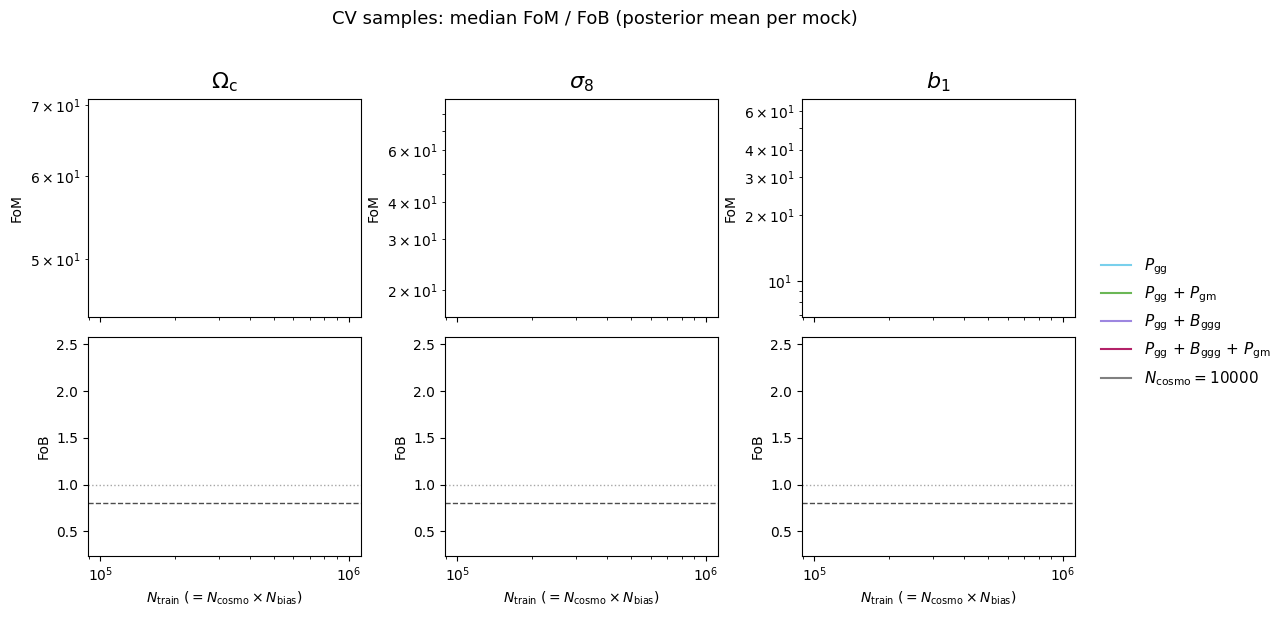

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_cvsample_mse_absdelta.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_cvsample_mse_absdelta.png


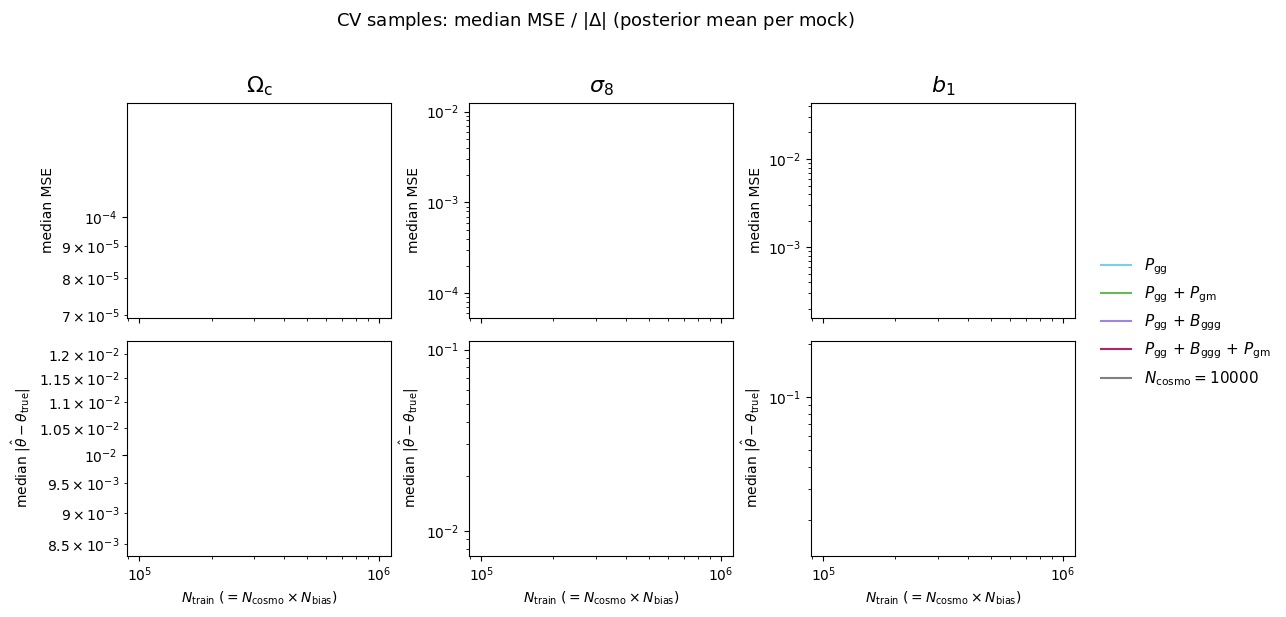

In [12]:
plot_conv_fom_fob(
    df_cv_sample,
    title="CV samples: median FoM / FoB (posterior mean per mock)",
    save_name="fig_cvsample_fom_fob",
)
plot_conv_mse_absdelta(
    df_cv_sample,
    title=r"CV samples: median MSE / $|\Delta|$ (posterior mean per mock)",
    save_name="fig_cvsample_mse_absdelta",
)


## 4. SHAMe OOD mock

Single SHAMe out-of-distribution mock at $\bar n=2.2\times10^{-4}$. Same as the CV-mean section: **marginal MAP** + posterior covariance for FoM/FoB (one observation, no aggregation).

The full $P_{\mathrm{gg}}+B+P_{\mathrm{gm}}$ grid is complete; $P_{\mathrm{gg}}$-only is mostly complete. $P_{\mathrm{gg}}+P_{\mathrm{gm}}$ and $P_{\mathrm{gg}}+B$ are filling in from inference jobs (missing $(n_{\mathrm{cosmo}},b_x)$ points print as MISSING).


In [13]:
df_ood = collect_all_combos(TEST_CFGS["ood"])
df_ood.head()


=== SHAMe OOD (MAP): $P_\mathrm{gg}(k)$ ===
tag_test=_shame_pk_nbar0.00022  point_est=map  aggregate=identity
grid: 6 bx × 7 n_cosmo = 42 points

OK       [$P_\mathrm{gg}(k)$] bx=1, n_cosmo=500: loaded samples_test_shame_pk_nbar0.00022_pred.npy (done): usable=1/1
OK       [$P_\mathrm{gg}(k)$] bx=1, n_cosmo=1000: loaded samples_test_shame_pk_nbar0.00022_pred.npy (done): usable=1/1
OK       [$P_\mathrm{gg}(k)$] bx=1, n_cosmo=2000: loaded samples_test_shame_pk_nbar0.00022_pred.npy (done): usable=1/1
OK       [$P_\mathrm{gg}(k)$] bx=1, n_cosmo=4000: loaded samples_test_shame_pk_nbar0.00022_pred.npy (done): usable=1/1
OK       [$P_\mathrm{gg}(k)$] bx=1, n_cosmo=6000: loaded samples_test_shame_pk_nbar0.00022_pred.npy (done): usable=1/1
OK       [$P_\mathrm{gg}(k)$] bx=1, n_cosmo=8000: loaded samples_test_shame_pk_nbar0.00022_pred.npy (done): usable=1/1
OK       [$P_\mathrm{gg}(k)$] bx=1, n_cosmo=10000: loaded samples_test_shame_pk_nbar0.00022_pred.npy (done): usable=1/1
OK       [$P_\mathrm{

,bx,n_cosmo,n_sims,n_cov,n_stored,status,kind,point_est,aggregate,fom_omega_m,...,fob_b1,mse_omega_m,absdelta_omega_m,mse_sigma8,absdelta_sigma8,mse_b1,absdelta_b1,fom_3d,fob3,stat_combo
0,1,500,500,1,1,complete,done,map,identity,32.800357,...,0.262098,0.000623,0.024956,0.008513,0.092264,0.002529,0.050288,3835.097945,1.929302,$P_\mathrm{gg}(k)$
1,1,1000,1000,1,1,complete,done,map,identity,25.918200,...,0.156047,0.000049,0.007000,0.007285,0.085353,0.001543,0.039275,2327.506592,1.685957,$P_\mathrm{gg}(k)$
2,1,2000,2000,1,1,complete,done,map,identity,37.865756,...,0.451012,0.000355,0.018845,0.008538,0.092401,0.007383,0.085926,4233.633488,2.019783,$P_\mathrm{gg}(k)$
3,1,4000,4000,1,1,complete,done,map,identity,29.589512,...,0.554944,0.000018,0.004227,0.006856,0.082801,0.009449,0.097206,3790.747033,1.714145,$P_\mathrm{gg}(k)$
4,1,6000,6000,1,1,complete,done,map,identity,39.600838,...,0.551923,0.000005,0.002343,0.008093,0.089964,0.008048,0.089712,5462.632824,1.863898,$P_\mathrm{gg}(k)$


Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_ood_fom_fob.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_ood_fom_fob.png


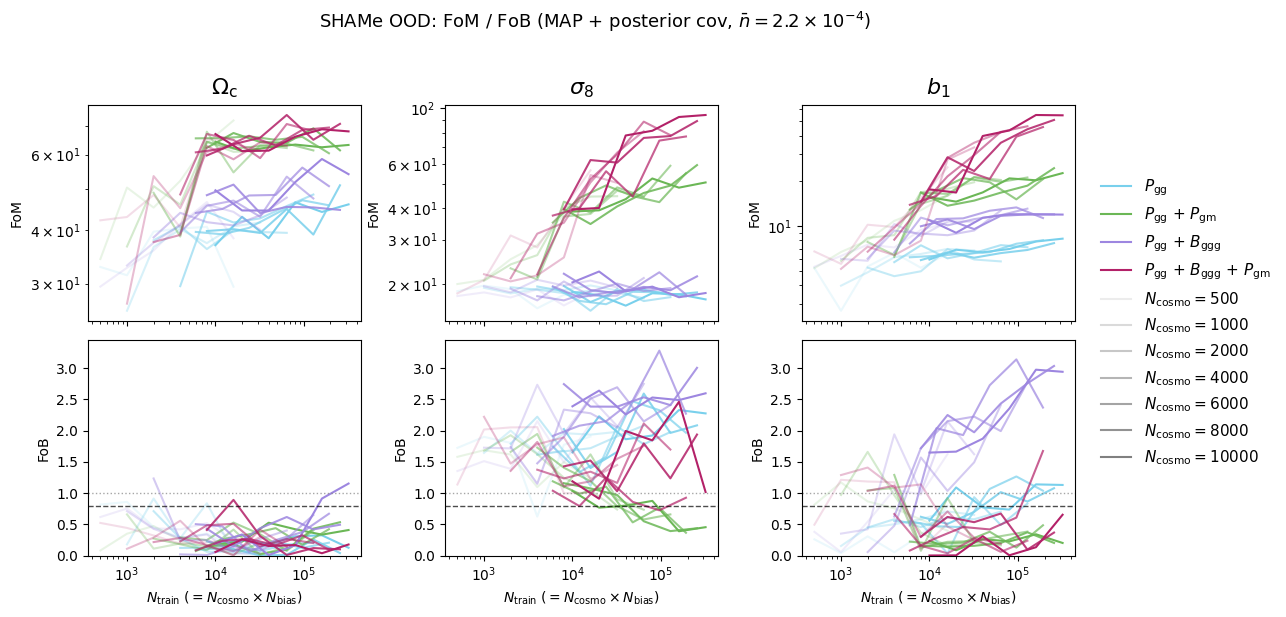

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_ood_fom3d_fob3.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_ood_fom3d_fob3.png


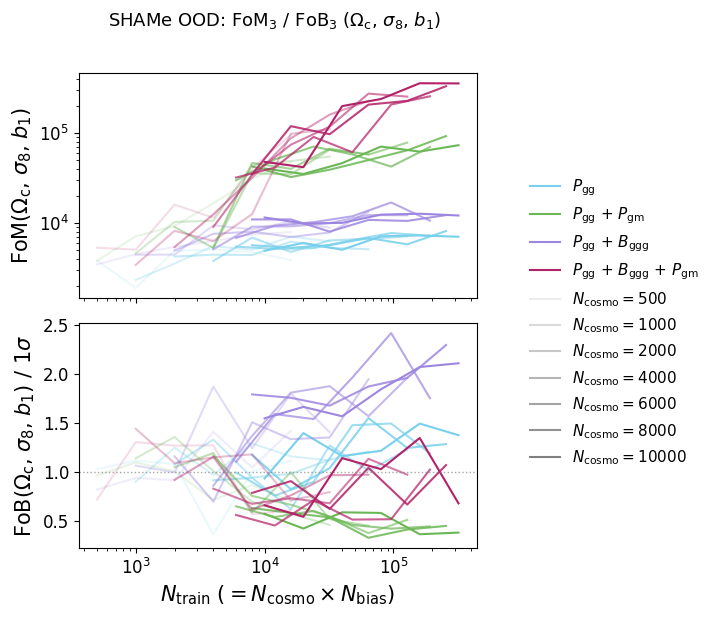

Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_ood_fom3d_fob3_pk_full.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_ood_fom3d_fob3_pk_full.png


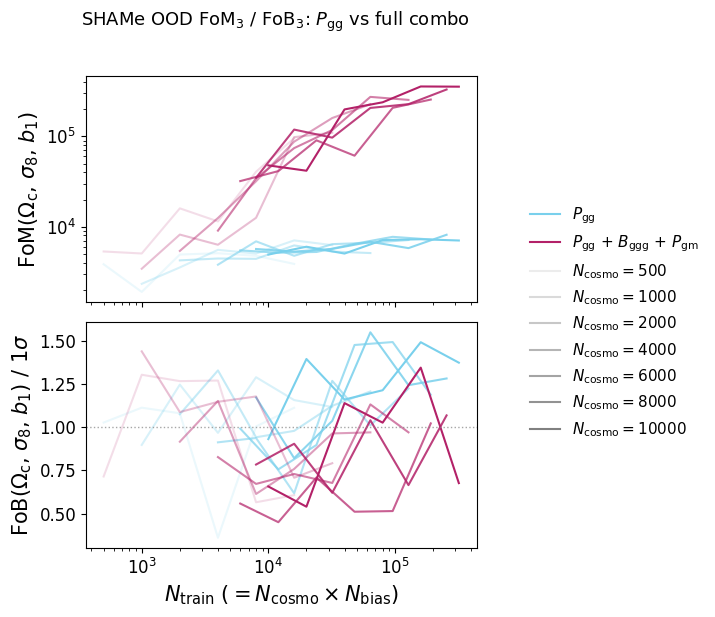

In [ ]:
plot_conv_fom_fob(
    df_ood,
    title=r"SHAMe OOD: FoM / FoB (MAP + posterior cov, $\bar n=2.2\times10^{-4}$)",
    save_name="fig_ood_fom_fob",
)
plot_conv_fom3d_fob3(
    df_ood,
    title=r"SHAMe OOD: FoM$_3$ / FoB$_3$ ($\Omega_\mathrm{c}$, $\sigma_8$, $b_1$)",
    save_name="fig_ood_fom3d_fob3",
)


## 5. PP plots — 3D joint coverage ($\Omega_\mathrm{c}$, $\sigma_8$, $b_1$)

Joint highest-posterior-density (HPD) coverage of the three key parameters. For each mock, the rank is the posterior mass inside the Mahalanobis ellipsoid (in physical $\Omega_\mathrm{c}$, $\sigma_8$, $b_1$) that just contains the true point. Well-calibrated posteriors have ranks $\sim U(0,1)$, so the PP curve (empirical CDF of ranks vs nominal credibility) follows the diagonal.

Test sets:
- **Coverage LH** — 1000 varying cosmologies / bias
- **Fixed-cosmo samples** — 1000 SHAMe mocks at the same cosmology (cosmic variance)

Fiducial training: $n_\mathrm{cosmo}=10\,000$, $b_x=32$. A second figure per test set shows $n_\mathrm{cosmo}$ dependence at $b_x=32$ (fixed-cosmo sample inference is currently only available at the fiducial training point).


In [7]:
# --- 3D PP helpers (physical Ωc, σ8, b1) ---
CRED_LEVELS = np.linspace(0.0, 1.0, 51)
NAMES_RP_3D = ["omega_cold", "sigma8_cold", "sigma8_cold_x_b1"]
N_COSMO_PP = 10000
BX_PP = 32


def physical_from_rp(arr):
    """Reparam (Ωc, σ8, σ8 b1) → physical (Ωc, σ8, b1). ``arr`` is (..., 3)."""
    out = np.empty_like(arr, dtype=np.float64)
    out[..., 0] = arr[..., 0]
    out[..., 1] = arr[..., 1]
    with np.errstate(divide="ignore", invalid="ignore"):
        out[..., 2] = arr[..., 2] / arr[..., 1]
    return out


def load_theta_true_phys3(tag_params_test, tag_biasparams_test, *, bx=BX_PP):
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, TAG_BIASPARAMS_TRAIN, bx=bx,
    )
    theta = data_loader.load_theta_test(
        tag_params_test, tag_biasparams_test,
        cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
    )
    theta = np.atleast_2d(np.asarray(theta, dtype=float))
    if tag_reparam:
        theta_rp, names_rp = ui.reparameterize_theta(theta, list(param_vary))
    else:
        theta_rp, names_rp = theta, list(param_vary)
    names_rp = list(names_rp)
    idxs = [names_rp.index(pn) for pn in NAMES_RP_3D]
    return physical_from_rp(np.asarray(theta_rp, dtype=float)[:, idxs])


def load_samples_phys3(tag_inf, tag_test):
    """Return (samples_phys, ok_mask) with samples_phys (n_draw, n_ok, 3) in physical 3D."""
    fn, _kind = _coverage_samples_path(tag_inf, tag_test)
    if fn is None:
        return None
    model_dir = dir_sbi / f"sbi{tag_inf}"
    fn_pn = model_dir / "param_names.txt"
    if not fn_pn.is_file():
        print(f"missing param_names.txt for {model_dir.name}")
        return None
    names_samp = list(np.loadtxt(fn_pn, dtype=str))
    try:
        idxs = [names_samp.index(pn) for pn in NAMES_RP_3D]
    except ValueError as exc:
        print(f"param mismatch in {model_dir.name}: {exc}")
        return None
    mm = np.load(fn, mmap_mode="r")
    if mm.ndim == 2:
        sub = np.asarray(mm[:, idxs], dtype=np.float64)[:, None, :]
    elif mm.ndim == 3:
        sub = np.asarray(mm[:, :, idxs], dtype=np.float64)
    else:
        print(f"unexpected sample ndim {mm.ndim} in {fn.name}")
        return None
    phys = physical_from_rp(sub)
    with np.errstate(all="ignore"):
        mu = np.nanmean(phys, axis=0)
    ok = np.all(np.isfinite(mu), axis=1)
    if not np.any(ok):
        print(f"no finite obs in {fn.name}")
        return None
    return phys[:, ok, :], ok


def joint_hpd_ranks(samples_phys, theta_true_phys, ridge=FOB_RIDGE):
    """HPD rank of truth under the 3D posterior ellipsoid, one rank per mock."""
    n_draw, n_obs, ndim = samples_phys.shape
    if ndim != 3:
        raise ValueError(f"expected 3 params, got {ndim}")
    truth = np.asarray(theta_true_phys, dtype=float)
    if truth.ndim == 1:
        truth = np.broadcast_to(truth, (n_obs, 3)).copy()
    if truth.shape != (n_obs, 3):
        raise ValueError(f"truth shape {truth.shape} != ({n_obs}, 3)")
    ranks = np.full(n_obs, np.nan)
    eye = np.eye(ndim)
    for i in range(n_obs):
        s = samples_phys[:, i, :]
        finite = np.all(np.isfinite(s), axis=1)
        s = s[finite]
        if s.shape[0] < ndim + 2:
            continue
        mu = np.mean(s, axis=0)
        cov = np.cov(s, rowvar=False) + ridge * eye
        sign, _ = np.linalg.slogdet(cov)
        cov_inv = np.linalg.inv(cov) if sign > 0 else np.linalg.pinv(cov)
        delta_s = s - mu
        d2_s = np.einsum("nj,jk,nk->n", delta_s, cov_inv, delta_s)
        delta_t = truth[i] - mu
        d2_t = float(delta_t @ cov_inv @ delta_t)
        ranks[i] = np.mean(d2_s <= d2_t)
    return ranks


def emp_coverage_from_ranks(ranks, cred_levels=CRED_LEVELS):
    r = np.asarray(ranks, dtype=float)
    r = r[np.isfinite(r)]
    if r.size == 0:
        return np.full(cred_levels.shape, np.nan)
    r.sort()
    return np.searchsorted(r, cred_levels, side="right") / r.size


def pp_curve_for_run(tag_inf, tag_test, theta_true_phys):
    loaded = load_samples_phys3(tag_inf, tag_test)
    if loaded is None:
        return None
    samples_phys, ok = loaded
    truth = np.asarray(theta_true_phys, dtype=float)
    if truth.ndim == 1 or truth.shape[0] == 1:
        truth_use = np.broadcast_to(np.reshape(truth, (3,)), (samples_phys.shape[1], 3)).copy()
    else:
        truth_use = truth[ok]
    ranks = joint_hpd_ranks(samples_phys, truth_use)
    n_use = int(np.sum(np.isfinite(ranks)))
    return dict(
        emp=emp_coverage_from_ranks(ranks),
        n_use=n_use,
        n_obs=int(samples_phys.shape[1]),
        median_rank=float(np.nanmedian(ranks)),
    )


def collect_pp_fiducial(tag_test_fn, theta_true_phys, *, n_cosmo=N_COSMO_PP, bx=BX_PP):
    out = []
    for statistics, tag_masks, color in zip(STATISTICS_ARR_FID, TAGS_MASK_FID, COLORS_FID):
        tag_inf = build_tag_inf_conv(bx, n_cosmo, statistics, tag_masks)
        tag_test = tag_test_fn(statistics, tag_masks)
        rec = pp_curve_for_run(tag_inf, tag_test, theta_true_phys)
        label = get_stat_label_short(statistics)
        if rec is None:
            print(f"MISSING  PP {label}: no samples (bx={bx}, n_cosmo={n_cosmo})")
            continue
        rec.update(label=label, color=color, statistics=statistics, tag_masks=tag_masks)
        print(f"OK       PP {label}: n={rec['n_use']}/{rec['n_obs']}, median rank={rec['median_rank']:.3f}")
        out.append(rec)
    return out


def collect_pp_ncosmo(tag_test_fn, theta_true_phys, *, bx=BX_PP, n_cosmo_values=None):
    n_cosmo_values = list(n_cosmo_values if n_cosmo_values is not None else n_cosmo_arr)
    by_stat = []
    for statistics, tag_masks, color in zip(STATISTICS_ARR_FID, TAGS_MASK_FID, COLORS_FID):
        curves = []
        for n_cosmo in n_cosmo_values:
            tag_inf = build_tag_inf_conv(bx, n_cosmo, statistics, tag_masks)
            tag_test = tag_test_fn(statistics, tag_masks)
            rec = pp_curve_for_run(tag_inf, tag_test, theta_true_phys)
            if rec is None:
                print(f"MISSING  PP {get_stat_label_short(statistics)} n_cosmo={n_cosmo}")
                continue
            rec.update(n_cosmo=n_cosmo)
            curves.append(rec)
            print(
                f"OK       PP {get_stat_label_short(statistics)} n_cosmo={n_cosmo}: "
                f"n={rec['n_use']}/{rec['n_obs']}"
            )
        by_stat.append(dict(
            label=get_stat_label_short(statistics),
            color=color,
            curves=curves,
        ))
    return by_stat


def plot_pp_stat_overlay(records, *, title, save_name):
    if not records:
        print(f"No PP curves to plot: {title}")
        return
    fig, ax = plt.subplots(figsize=(4.4, 4.2))
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.7, zorder=1)
    for rec in records:
        ax.plot(
            CRED_LEVELS, rec["emp"], color=rec["color"], lw=1.6,
            label=rec["label"], zorder=2,
        )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("credibility level")
    ax.set_ylabel("empirical coverage")
    ax.set_title(title, fontsize=12)
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    fig.tight_layout()
    save_figure(fig, save_name)
    plt.show()


def plot_pp_ncosmo_grid(by_stat, *, title, save_name, n_cosmo_values=None):
    n_cosmo_values = sorted(n_cosmo_values if n_cosmo_values is not None else n_cosmo_arr)
    fig, axes = plt.subplots(2, 2, figsize=(8.2, 8.0), sharex=True, sharey=True)
    axes = axes.ravel()
    for ax, block in zip(axes, by_stat):
        ax.plot([0, 1], [0, 1], "k--", lw=1.1, alpha=0.7, zorder=1)
        rgb = mcolors.to_rgb(block["color"])
        for rec in block["curves"]:
            alpha = n_cosmo_alpha(rec["n_cosmo"], n_cosmo_values)
            ax.plot(
                CRED_LEVELS, rec["emp"], color=(*rgb, alpha), lw=1.4, zorder=2,
            )
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(block["label"], fontsize=12, fontweight="bold")
    for ax in axes[2:]:
        ax.set_xlabel("credibility level")
    for ax in axes[::2]:
        ax.set_ylabel("empirical coverage")
    fig.suptitle(title, fontsize=13, y=1.01)
    h_nc, l_nc = _n_cosmo_legend_handles(n_cosmo_values)
    fig.legend(
        h_nc, l_nc, fontsize=10, loc="center left",
        bbox_to_anchor=(0.92, 0.5), frameon=False, labelcolor="black",
    )
    fig.tight_layout()
    fig.subplots_adjust(right=0.84)
    save_figure(fig, save_name)
    plt.show()


In [8]:
theta_true_cov_phys = load_theta_true_phys3(TAG_PARAMS_TEST_COV, TAG_BIASPARAMS_TEST_COV)
theta_true_fixed_phys = load_theta_true_phys3(TAG_PARAMS_TEST_FIXED, TAG_BIASPARAMS_TEST_FIXED)
print(
    "coverage truths:", theta_true_cov_phys.shape,
    "fixed truths:", theta_true_fixed_phys.shape,
    "fixed (Ωc, σ8, b1) =", theta_true_fixed_phys[0],
)


coverage truths: (1000, 3) fixed truths: (1, 3) fixed (Ωc, σ8, b1) = [0.3089     0.8159     0.47410742]


Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/pp3d_coverage_fiducial.pkl
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_coverage_pp3d.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_coverage_pp3d.png


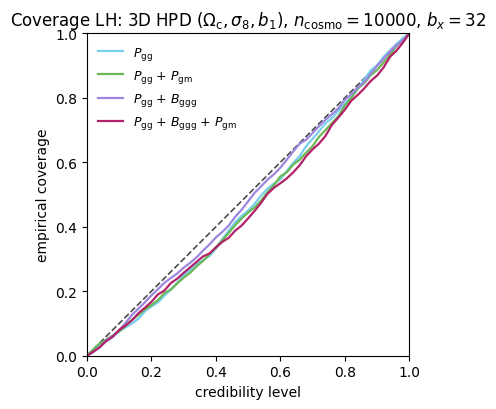

Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/pp3d_coverage_ncosmo_bx32.pkl
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_coverage_pp3d_ncosmo.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_coverage_pp3d_ncosmo.png


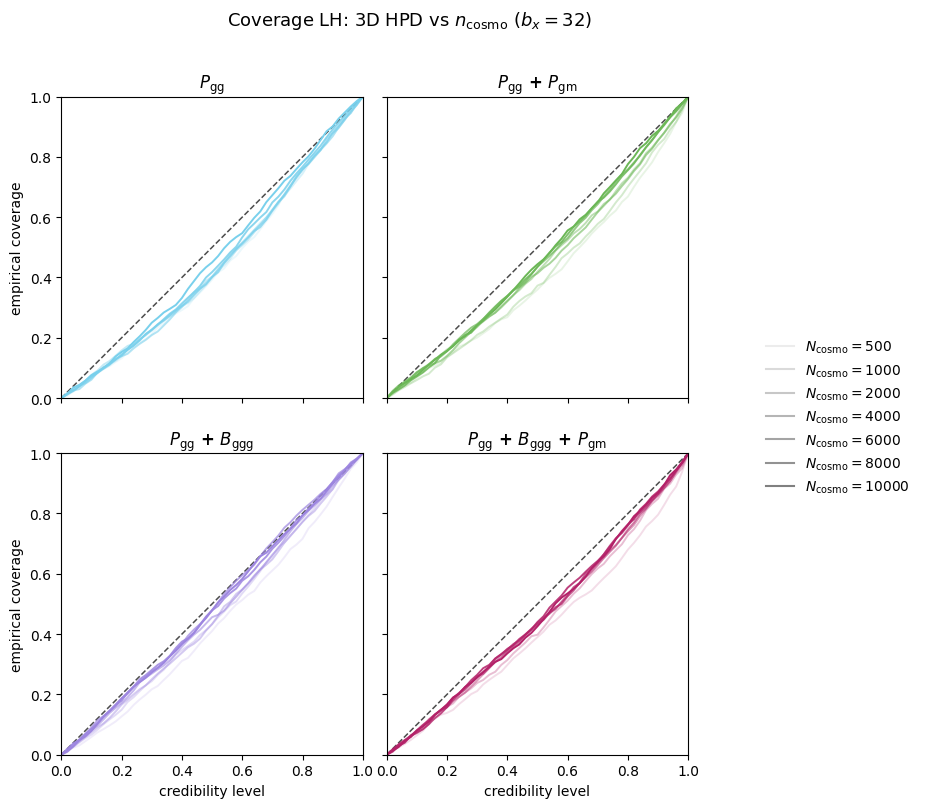

In [9]:
# Coverage LH: fiducial overlay + n_cosmo dependence at bx=32
pp_cov_fid = load_or_build(
    "pp3d_coverage_fiducial",
    lambda: collect_pp_fiducial(build_tag_test_coverage, theta_true_cov_phys),
)
plot_pp_stat_overlay(
    pp_cov_fid,
    title=r"Coverage LH: 3D HPD ($\Omega_\mathrm{c},\sigma_8,b_1$), "
          rf"$n_\mathrm{{cosmo}}={N_COSMO_PP}$, $b_x={BX_PP}$",
    save_name="fig_coverage_pp3d",
)

pp_cov_ncosmo = load_or_build(
    "pp3d_coverage_ncosmo_bx32",
    lambda: collect_pp_ncosmo(build_tag_test_coverage, theta_true_cov_phys, bx=BX_PP),
)
plot_pp_ncosmo_grid(
    pp_cov_ncosmo,
    title=rf"Coverage LH: 3D HPD vs $n_\mathrm{{cosmo}}$ ($b_x={BX_PP}$)",
    save_name="fig_coverage_pp3d_ncosmo",
)


Loaded cache: /home/kstoreyf/muchisimocks/figures/convergence_variations_cache/pp3d_cvsample_fiducial.pkl
Saved: /home/kstoreyf/muchisimocks/figures/2026-08-07_convergence_variations/fig_cvsample_pp3d.png
Saved: /home/kstoreyf/muchisimocks/figures/convergence_variations_latest/fig_cvsample_pp3d.png


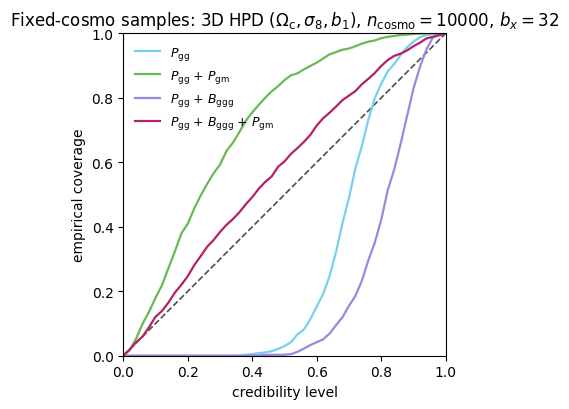

In [10]:
# Fixed-cosmo samples: fiducial overlay + n_cosmo dependence at bx=32
pp_cv_fid = load_or_build(
    "pp3d_cvsample_fiducial",
    lambda: collect_pp_fiducial(lambda s, m: build_tag_test_cv(s, m, mean=False), theta_true_fixed_phys),
)
plot_pp_stat_overlay(
    pp_cv_fid,
    title=r"Fixed-cosmo samples: 3D HPD ($\Omega_\mathrm{c},\sigma_8,b_1$), "
          rf"$n_\mathrm{{cosmo}}={N_COSMO_PP}$, $b_x={BX_PP}$",
    save_name="fig_cvsample_pp3d",
)